In [1]:
import os
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import dump


# Criar pastas corretas
os.makedirs("../data", exist_ok=True)
os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

In [2]:
df = pd.read_csv('../data/breast_cancer_original.csv')
X = df.drop(columns=['target'])
y = df['target']
num_cols = X.columns.tolist()

In [3]:
num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy='mean')),
('scaler', StandardScaler())
])


preproc = ColumnTransformer([
('num', num_pipeline, num_cols)
])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, stratify=y, random_state=42
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (398, 30) Test: (171, 30)


In [8]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=300, random_state=42)
}

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ('preproc', preproc),
        ('clf', clf)
    ])
    
    start = time.time()
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    
    cv_results[name] = {
        'accuracy_mean': res['test_accuracy'].mean(),
        'precision_mean': res['test_precision_macro'].mean(),
        'recall_mean': res['test_recall_macro'].mean(),
        'f1_mean': res['test_f1_macro'].mean(),
        'time_cv_seconds': elapsed
    }

cv_df = pd.DataFrame(cv_results).T
print("\n--- RESULTADOS CV ---")
print(cv_df)



--- RESULTADOS CV ---
                    accuracy_mean  precision_mean  recall_mean   f1_mean  \
LogisticRegression       0.973669        0.977256     0.967610  0.971387   
RandomForest             0.952569        0.953083     0.947964  0.948947   
GradientBoosting         0.956109        0.959475     0.947916  0.952310   

                    time_cv_seconds  
LogisticRegression         2.207656  
RandomForest               1.973980  
GradientBoosting           1.986780  


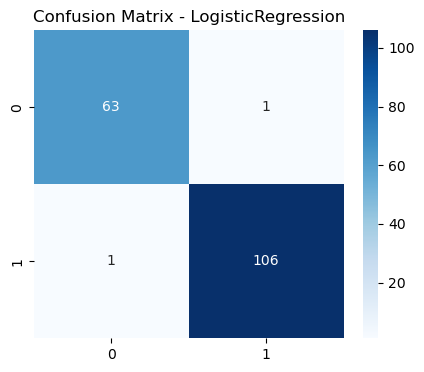

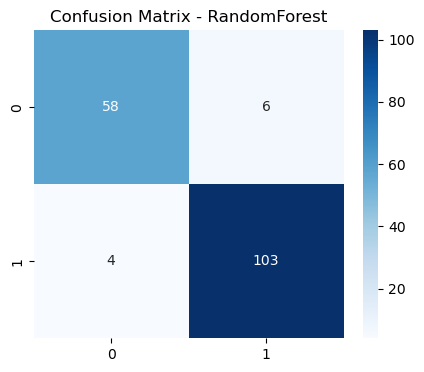

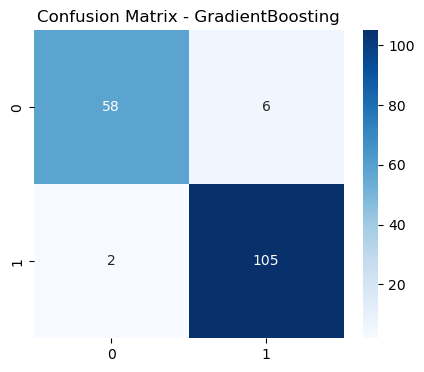


Métricas salvas em ../results/metrics_table.csv
                model  train_time_s  predict_time_s  accuracy_test  \
0  LogisticRegression      0.070329        0.006280       0.988304   
1        RandomForest      0.448123        0.019744       0.941520   
2    GradientBoosting      1.201179        0.004538       0.953216   

   precision_macro_test  recall_macro_test  f1_macro_test  
0              0.987515           0.987515       0.987515  
1              0.940219           0.934433       0.937169  
2              0.956306           0.943779       0.949393  


In [10]:
metrics_list = []

for name, clf in models.items():
    pipe = Pipeline([
        ('preproc', preproc),
        ('clf', clf)
    ])
    
    # treinamento
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    # predição
    t0 = time.time()
    y_pred = pipe.predict(X_test)
    predict_time = time.time() - t0

    # métricas
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # salvar matriz de confusão
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(f'../results/confusion_matrix_{name.lower()}.png', bbox_inches='tight')
    plt.show()

    # salvar modelo
    dump(pipe, f'../models/{name.lower()}_model.joblib')

    metrics_list.append({
        'model': name,
        'train_time_s': train_time,
        'predict_time_s': predict_time,
        'accuracy_test': report['accuracy'],
        'precision_macro_test': report['macro avg']['precision'],
        'recall_macro_test': report['macro avg']['recall'],
        'f1_macro_test': report['macro avg']['f1-score']
    })

# salvar tabela final
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv('../results/metrics_table.csv', index=False)

print("\nMétricas salvas em ../results/metrics_table.csv")
print(metrics_df)
